<a href="https://colab.research.google.com/github/yusuf-codes10/deep-learning-misra-trup/blob/main/insects_ann_homework.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Insects ANN

## 1- Getting the data from kaggle

In [5]:
# STEP 1 — Set Kaggle credentials (run this first)
import os
from getpass import getpass

os.environ['KAGGLE_USERNAME'] = input("Enter Kaggle username: ")
os.environ['KAGGLE_API_TOKEN'] = getpass("Enter Kaggle API key: ")

Enter Kaggle username: youcefcopy
Enter Kaggle API key: ··········


In [6]:
# STEP 2 — Install Kaggle (run once per session)
!pip install -q kaggle

In [7]:
# STEP 3 — Download dataset
!kaggle datasets download -d ismail703/insects

Dataset URL: https://www.kaggle.com/datasets/ismail703/insects
License(s): unknown
100% 969M/969M [00:10<00:00, 94.9MB/s]



In [8]:
# STEP 4 — Unzip dataset
!unzip -q insects.zip

## 2- doing some EDA

In [9]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt

In [10]:
!ls

Ant  Beetle	Dragonfly  Grasshopper	Ladybug   sample_data  Wasp
Bee  Butterfly	Fly	   insects.zip	Mosquito  Spider


In [52]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    "insects",
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(224, 224),
    batch_size=32
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    "insects",
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(224, 224),
    batch_size=32
)

Found 7548 files belonging to 10 classes.
Using 6039 files for training.
Found 7548 files belonging to 10 classes.
Using 1509 files for validation.


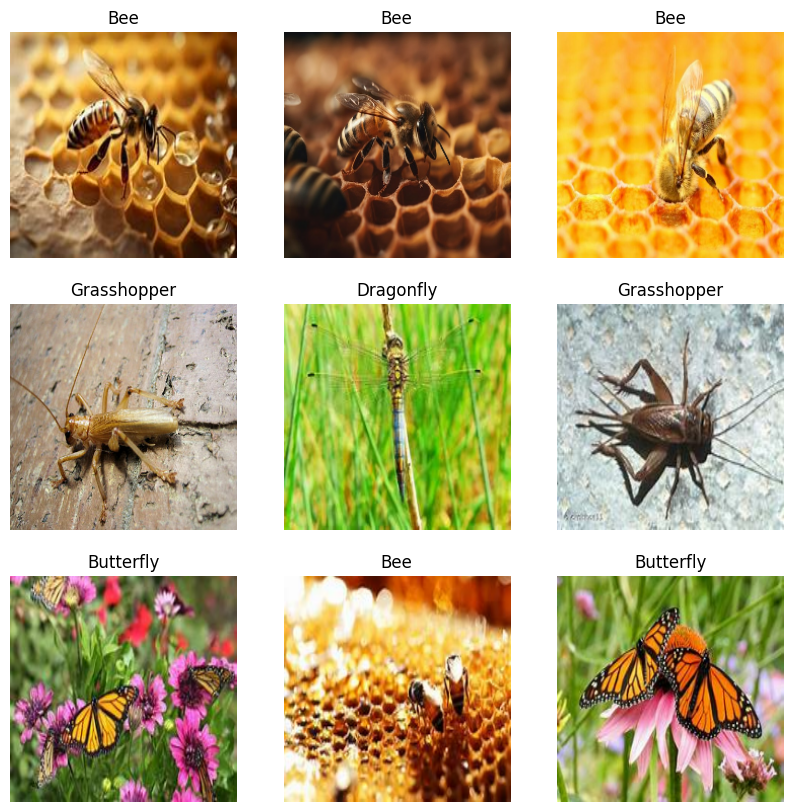

In [53]:
import matplotlib.pyplot as plt

for images, labels in train_ds.take(1):
    plt.figure(figsize=(10,10))

    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(train_ds.class_names[labels[i]])
        plt.axis("off")

In [18]:
dataset

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

In [20]:
!mkdir insects
!mv Ant Bee Beetle Butterfly Dragonfly Grasshopper Ladybug Mosquito Spider Wasp insects/

In [21]:
import tensorflow as tf

train_ds = tf.keras.utils.image_dataset_from_directory(
    "insects",              # your dataset path
    validation_split=0.2,
    subset="training",
    seed=123,               # IMPORTANT (keeps split consistent)
    image_size=(224, 224),
    batch_size=32
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    "insects",
    validation_split=0.2,
    subset="validation",
    seed=123,               # same seed!
    image_size=(224, 224),
    batch_size=32
)

Found 7725 files belonging to 10 classes.
Using 6180 files for training.
Found 7725 files belonging to 10 classes.
Using 1545 files for validation.


In [25]:
train_ds, val_ds

(<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>,
 <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>)

In [23]:
# input shape
for images, labels in train_ds.take(1):
    print(images.shape)
    print(labels.shape)

(32, 224, 224, 3)
(32,)


In [32]:
for images, labels in val_ds.take(1):
    print(images.shape)
    print(labels.shape)

(32, 224, 224, 3)
(32,)


In [34]:
x_train = train_ds
x_val = val_ds

In [36]:
type(x_train[0])

TypeError: '_PrefetchDataset' object is not subscriptable

In [30]:
# List all files recursively in the 'insects' directory to identify any non-image files
!find insects -type f

Streaming output truncated to the last 5000 lines.
insects/Ant/Ant_383.jpg
insects/Ant/Ant_594.jpg
insects/Ant/Ant_539.jpg
insects/Ant/Ant_555.jpg
insects/Ant/Ant_626.jpg
insects/Ant/Ant_170.jpg
insects/Ant/Ant_588.jpg
insects/Ant/Ant_700.jpg
insects/Ant/Ant_477.jpg
insects/Ant/Ant_254.jpg
insects/Ant/Ant_731.jpg
insects/Ant/Ant_76.jpg
insects/Ant/Ant_117.jpg
insects/Ant/Ant_20.jpg
insects/Ant/Ant_273.jpg
insects/Ant/Ant_575.jpg
insects/Ant/Ant_325.jpg
insects/Ant/Ant_225.jpg
insects/Ant/Ant_269.jpg
insects/Ant/Ant_397.jpg
insects/Ant/Ant_649.jpg
insects/Ant/Ant_287.jpg
insects/Ant/Ant_75.jpg
insects/Ant/Ant_608.jpg
insects/Ant/Ant_621.jpg
insects/Ant/Ant_318.jpg
insects/Ant/Ant_245.jpg
insects/Ant/Ant_174.jpg
insects/Ant/Ant_5.jpg
insects/Ant/Ant_601.jpg
insects/Ant/Ant_439.jpg
insects/Ant/Ant_71.jpg
insects/Ant/Ant_21.jpg
insects/Ant/Ant_60.jpg
insects/Ant/Ant_709.jpg
insects/Ant/Ant_578.jpg
insects/Ant/Ant_104.jpg
insects/Ant/Ant_595.jpg
insects/Ant/Ant_657.jpg
insects/Ant/Ant_73.jp

In [37]:
# To get one batch of images + labels
for images, labels in x_train.take(1):
    print(images.shape)   # (32, 224, 224, 3)  — 32 images
    print(labels.shape)   # (32,)               — 32 labels
    print(images[0])      # raw pixel values of the first image
    print(labels[0])      # label of the first image

(32, 224, 224, 3)
(32,)
tf.Tensor(
[[[ 81.741066  101.68272    41.947063 ]
  [ 96.21429   126.21429    76.21429  ]
  [105.89286   129.89285    79.89286  ]
  ...
  [  0.          5.          0.       ]
  [  0.          4.          0.       ]
  [  0.          5.          0.       ]]

 [[ 55.642853   78.64285     0.       ]
  [ 85.81568   107.81568    43.815685 ]
  [104.366066  128.36606    78.366066 ]
  ...
  [  0.          5.          0.       ]
  [  0.          5.          0.       ]
  [  0.          5.          0.       ]]

 [[ 46.252872   68.25287     0.       ]
  [ 59.071743   82.07174     0.6339264]
  [ 89.87149   114.87149    59.87149  ]
  ...
  [  0.          5.          0.       ]
  [  0.          5.          0.       ]
  [  0.          5.          0.       ]]

 ...

 [[ 95.54464   119.54464     9.544642 ]
  [ 96.        120.         10.       ]
  [ 95.        119.          7.       ]
  ...
  [ 24.         41.          0.       ]
  [ 24.         41.          0.       ]
  [ 24.  

## 3- training the model in 3 steps

### 3-1 Model Archetecture

In [59]:
model = keras.models.Sequential([
    keras.layers.Rescaling(1./255, input_shape=(224, 224, 3)),
    keras.layers.Flatten(),  # THIS is what converts (224, 224, 3) → 150528 flat values
    keras.layers.Dense(300, activation="relu"),
    keras.layers.Dense(100, activation="relu"),
    keras.layers.Dense(10, activation="softmax")
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


### 3-2 Compile (loss, function, optimizer and metrics)

In [62]:
model.compile(loss="sparse_categorical_crossentropy", metrics=["accuracy"], optimizer='adam')

In [57]:
# verify how many output neurons we need
print(train_ds.class_names)
print(len(train_ds.class_names))

['Ant', 'Bee', 'Beetle', 'Butterfly', 'Dragonfly', 'Grasshopper', 'Ladybug', 'Mosquito', 'Spider', 'Wasp']
10


### 3-3 Fitting (epochs, batchs and the val, train)

In [ ]:
history = model.fit(train_ds, epochs = 30, validation_data = val_ds, batch_size=32)

Epoch 1/30
117/189 ━━━━━━━━━━━━━━━━━━━━ 1:25 1s/step - accuracy: 0.1178 - loss: 4.5296

### 3-4 Preporccessing

In [41]:
import os
import imghdr

# Check and remove bad files
bad_files = []
for root, dirs, files in os.walk("insects"):
    for fname in files:
        fpath = os.path.join(root, fname)
        img_type = imghdr.what(fpath)
        if img_type not in ("jpeg", "png", "gif", "bmp"):
            bad_files.append(fpath)
            os.remove(fpath)

print(f"Removed {len(bad_files)} bad files:")
for f in bad_files:
    print(f)

/tmp/ipykernel_2523/2976494197.py:2: DeprecationWarning: 'imghdr' is deprecated and slated for removal in Python 3.13
  import imghdr


Removed 177 bad files:
insects/Ladybug/Ladybug_291.jpg
insects/Ladybug/Ladybug_90.jpg
insects/Ladybug/Ladybug_38.jpg
insects/Ladybug/Ladybug_39.jpg
insects/Ladybug/Ladybug_380.jpg
insects/Ladybug/Ladybug_175.jpg
insects/Ladybug/Ladybug_130.jpg
insects/Ladybug/Ladybug_361.jpg
insects/Ladybug/Ladybug_27.jpg
insects/Ladybug/Ladybug_176.jpg
insects/Ladybug/Ladybug_98.jpg
insects/Ladybug/Ladybug_294.jpg
insects/Ladybug/Ladybug_651.jpg
insects/Ladybug/Ladybug_114.jpg
insects/Ladybug/Ladybug_638.jpg
insects/Ladybug/Ladybug_404.jpg
insects/Ladybug/Ladybug_244.jpg
insects/Ladybug/Ladybug_111.jpg
insects/Ladybug/Ladybug_26.jpg
insects/Butterfly/Butterfly_761.jpg
insects/Butterfly/Butterfly_274.jpg
insects/Butterfly/Butterfly_151.jpg
insects/Butterfly/Butterfly_140.jpg
insects/Butterfly/Butterfly_40.jpg
insects/Butterfly/Butterfly_275.jpg
insects/Butterfly/Butterfly_276.jpg
insects/Butterfly/Butterfly_74.jpg
insects/Butterfly/Butterfly_148.jpg
insects/Butterfly/Butterfly_211.jpg
insects/Butterfly